In [2]:
import os
os.chdir("..")   # notebooks 的上一级就是项目根目录


In [1]:
from datasets import load_dataset

ds = load_dataset("imdb")
ds


d:\ProgrammingProjects\text-classification-baseline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\ProgrammingProjects\text-classification-baseline\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\李广鹏\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator.

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [2]:
print(ds)
print(ds["train"][0]["label"])
print(ds["train"][0]["text"][:200])


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
0
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev


In [3]:
from sklearn.model_selection import train_test_split

X = ds["train"]["text"]
y = ds["train"]["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,   # 保持正负比例一致（推荐）
)

print("train:", len(X_train), "val:", len(X_val))


train: 20000 val: 5000


In [4]:
from collections import Counter

print("train label dist:", Counter(y_train))
print("val   label dist:", Counter(y_val))


train label dist: Counter({1: 10000, 0: 10000})
val   label dist: Counter({1: 2500, 0: 2500})


In [5]:
X_test = ds["test"]["text"]
y_test = ds["test"]["label"]

print("test:", len(X_test))


test: 25000


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",   # 英文任务推荐
    max_features=50000,     # 维度上限（baseline 常用）
    ngram_range=(1, 2),     # 1-gram + 2-gram
)

X_train_vec = tfidf.fit_transform(X_train)  # 只在训练集 fit
X_val_vec = tfidf.transform(X_val)
X_test_vec = tfidf.transform(X_test)

print("train vec:", X_train_vec.shape)
print("val   vec:", X_val_vec.shape)
print("test  vec:", X_test_vec.shape)


train vec: (20000, 50000)
val   vec: (5000, 50000)
test  vec: (25000, 50000)


In [7]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# val 上先看效果（用于调参）
val_pred = clf.predict(X_val_vec)
val_acc = accuracy_score(y_val, val_pred)
val_cm = confusion_matrix(y_val, val_pred)

print("VAL accuracy:", val_acc)
print("VAL confusion matrix:\n", val_cm)
print(classification_report(y_val, val_pred, digits=4))


VAL accuracy: 0.8934
VAL confusion matrix:
 [[2191  309]
 [ 224 2276]]
              precision    recall  f1-score   support

           0     0.9072    0.8764    0.8916      2500
           1     0.8805    0.9104    0.8952      2500

    accuracy                         0.8934      5000
   macro avg     0.8939    0.8934    0.8934      5000
weighted avg     0.8939    0.8934    0.8934      5000



In [9]:
test_pred = clf.predict(X_test_vec)
test_acc = accuracy_score(y_test, test_pred)
test_cm = confusion_matrix(y_test, test_pred)

print("TEST accuracy:", test_acc)
print("TEST confusion matrix:\n", test_cm)
print(classification_report(y_test, test_pred, digits=4))


TEST accuracy: 0.87828
TEST confusion matrix:
 [[10947  1553]
 [ 1490 11010]]
              precision    recall  f1-score   support

           0     0.8802    0.8758    0.8780     12500
           1     0.8764    0.8808    0.8786     12500

    accuracy                         0.8783     25000
   macro avg     0.8783    0.8783    0.8783     25000
weighted avg     0.8783    0.8783    0.8783     25000



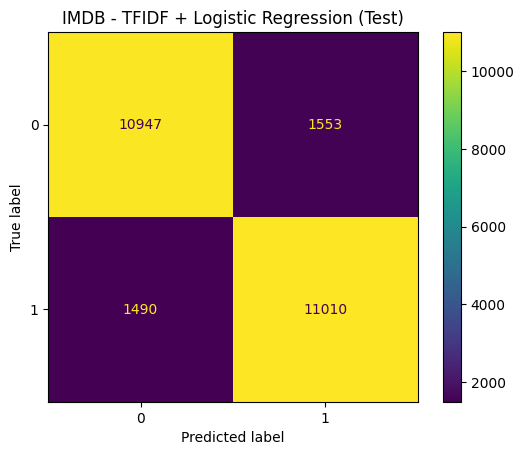

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.title("IMDB - TFIDF + Logistic Regression (Test)")
plt.show()



In [12]:
# src/data.py
from datasets import load_dataset
from sklearn.model_selection import train_test_split


def load_imdb_splits(test_size: float = 0.2, seed: int = 42):
    ds = load_dataset("imdb")

    X = ds["train"]["text"]
    y = ds["train"]["label"]

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )

    X_test = ds["test"]["text"]
    y_test = ds["test"]["label"]

    return X_train, y_train, X_val, y_val, X_test, y_test


In [ ]:
# src/train.py
import argparse
from pathlib import Path
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from src.data import load_imdb_splits


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--test_size", type=float, default=0.2)
    p.add_argument("--seed", type=int, default=42)
    p.add_argument("--max_features", type=int, default=50000)
    p.add_argument("--ngram_max", type=int, default=2)
    p.add_argument("--C", type=float, default=1.0)
    p.add_argument("--max_iter", type=int, default=1000)
    p.add_argument("--out_dir", type=str, default="artifacts")
    return p.parse_args()


def main():
    args = parse_args()

    X_train, y_train, X_val, y_val, _, _ = load_imdb_splits(
        test_size=args.test_size, seed=args.seed
    )

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=args.max_features,
        ngram_range=(1, args.ngram_max),
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_val_vec = vectorizer.transform(X_val)

    clf = LogisticRegression(C=args.C, max_iter=args.max_iter)
    clf.fit(X_train_vec, y_train)

    val_pred = clf.predict(X_val_vec)
    val_acc = accuracy_score(y_val, val_pred)
    val_cm = confusion_matrix(y_val, val_pred)

    print(f"[VAL] accuracy: {val_acc:.4f}")
    print("[VAL] confusion matrix:\n", val_cm)
    print("[VAL] classification report:\n", classification_report(y_val, val_pred, digits=4))

    out_dir = Path(args.out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    joblib.dump(vectorizer, out_dir / "tfidf.joblib")
    joblib.dump(clf, out_dir / "logreg.joblib")

    print(f"Saved: {(out_dir / 'tfidf.joblib').as_posix()}")
    print(f"Saved: {(out_dir / 'logreg.joblib').as_posix()}")


if __name__ == "__main__":
    main()
